# Búsqueda de Grover para la recuperación de secretos 
# LWE

In [89]:
import numpy as np
from qiskit.visualization import array_to_latex, plot_histogram
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
import math
from qiskit.quantum_info import Statevector

### b = As + e (mod q)
A es pública <br>
s es secreto <br>
Para romperlo hay que obtener s <br>

In [90]:
def generar_lwe(n, m, q):

    #Generar matriz A aleatoria
    A = np.random.randint(0, q, size=(m, n))

    #Generar secreto aleatorio
    s = np.random.randint(0, q, size=n)

    #Errores
    em1 = -1
    e0 = 0
    e1 = 1
    
    #Calcular cada b con formula b = A*s + e mod q
    As = np.matmul(A, s)
    #display(array_to_latex(As, prefix="A*s"))
    bm1 = (As + em1) % q
    b0 = (As + e0) % q
    b1 = (As + e1) % q
    
    return A, s, bm1, b0, b1

El ataque consiste en probar diferentes s, calcular el residuo r = b − As (mod q) y comprobar si es pequeño

In [91]:
def calcular_residuo(A, s, b, q):
    
    #Calcular residuo con r = b - A*s mod q
    As = np.matmul(A, s)
    r = (b - As) % q
    return r

### Query

f(s) = 1 si cada componente de (b − As mod q) tiene distancia circular ≤ τ <br>
f(s) = 0 en caso contrario

Distancia circular = min(r, q −r)

In [92]:
def cumple_condicion(r, q):
    
    #Sacar el minimo entre r y q-r para cada elemento del vector
    dist = np.minimum(r, q - r)
    print(dist)

    #Devuelve true si todos los elementos son menores o iguales a 1
    if np.all(dist <= 1):
        return True
    else:
        return False

### Oracle


Construye un oráculo de fase en Qiskit que aplique un cambio de signo
al estado |s′⟩ marcado. Con un solo estado marcado y 3 qubits, esto
se implementa con puertas X (para negar los bits que sean 0 en la
representación binaria de s) rodeando un multi-controlled Z.

In [93]:
def vector_a_bits(s, num_bits, n):
    s_bits = np.array([], dtype=int)
    for i in range(n):
        bits = [int(b) for b in format(s[i], f'0{num_bits}b')]
        s_bits = np.append(s_bits, bits)
    return s_bits

In [94]:
def oracle(num_qubits, num_bits, s, n):
    
    circuito = QuantumCircuit(num_qubits)

    #Pasar s a bits
    display(array_to_latex(s, prefix="s"))
    s_bits = vector_a_bits(s, num_bits, n)
    print("s en bits:", s_bits)

    #Aplicar X a los 0
    for bit in enumerate(s_bits):
        if bit[1] == 0:
            circuito.x(bit[0])

    #Aplicar multicontrolled Z para cambiar fase si s es solución
    circuito.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
    
    #Volver a aplicar X
    for bit in enumerate(s_bits):
        if bit[1] == 0:
            circuito.x(bit[0])
    
    return circuito

### Caso n=1, m=3, q=8, número de qubits = 3

In [95]:
n1 = 1
m1 = 3
q1 = 8
num_qubits1 = 3
num_bits1 = int(np.ceil(np.log2(q1)))

In [96]:
#Generar instancia LWE

A1, s1, bm11, b10, b11 = generar_lwe(n1, m1 ,q1)

display(array_to_latex(A1, prefix="A1"))
display(array_to_latex(s1, prefix="s1"))

display(array_to_latex(bm11, prefix="bm11"))
display(array_to_latex(b10, prefix="b10"))
display(array_to_latex(b11, prefix="b11"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [97]:
#Calcular residuos para -1 0 y 1

rm11 = calcular_residuo(A1, s1, bm11, q1)
r10 = calcular_residuo(A1, s1, b10, q1)
r11 = calcular_residuo(A1, s1, b11, q1)

display(array_to_latex(rm11, prefix="rm11"))
display(array_to_latex(r10, prefix="r10"))
display(array_to_latex(r11, prefix="r11"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [98]:
#Comprobar condición

print("bm1 cumple condicion:", cumple_condicion(rm11, q1))
print("b0 cumple condicion:", cumple_condicion(r10, q1))    
print("b1 cumple condicion:", cumple_condicion(r11, q1))

[1 1 1]
bm1 cumple condicion: True
[0 0 0]
b0 cumple condicion: True
[1 1 1]
b1 cumple condicion: True


<IPython.core.display.Latex object>

s en bits: [1 0 1]


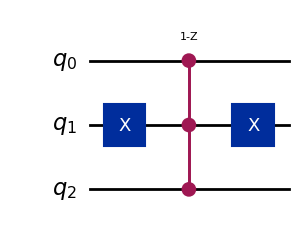

In [99]:
circuito1 = oracle(num_qubits1, num_bits1, s1, n1)
display(circuito1.draw(output="mpl"))

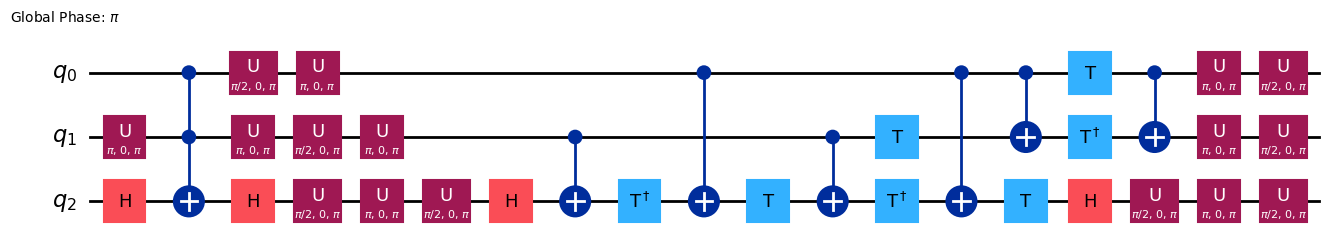

In [100]:
#Construir el operador de Grover

grover_op1 = grover_operator(circuito1)
grover_op1.decompose().draw(output="mpl", style="iqp")

k=1:


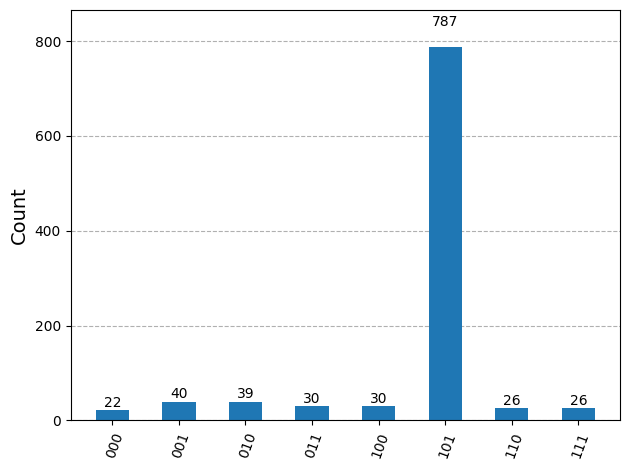

k=2:


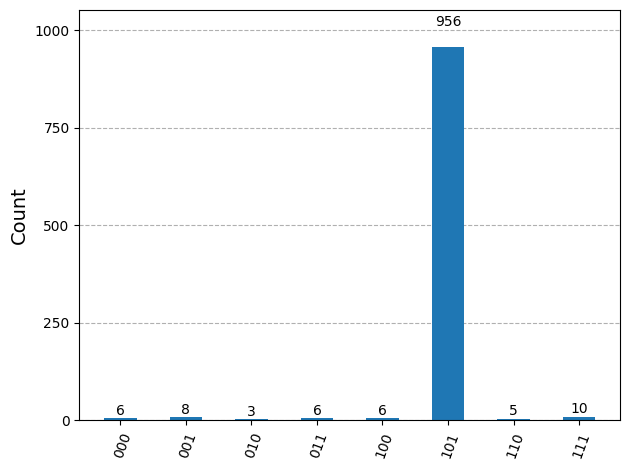

k=3:


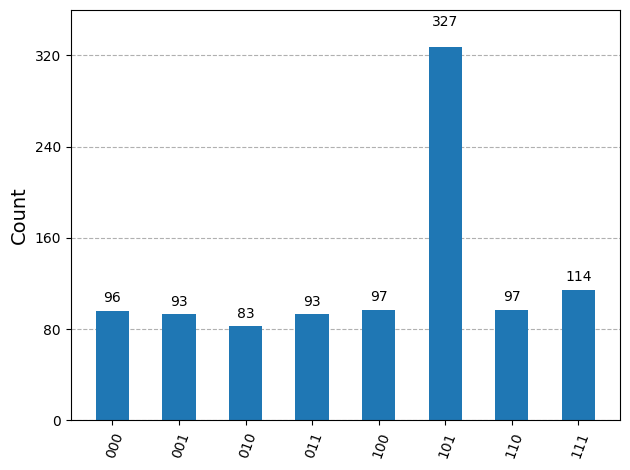

k=4:


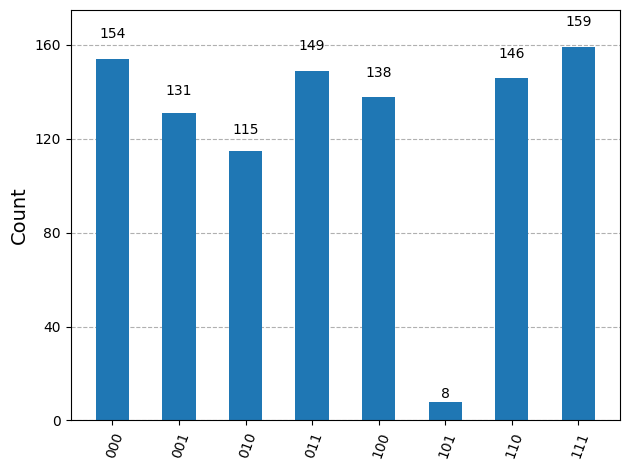

k=5:


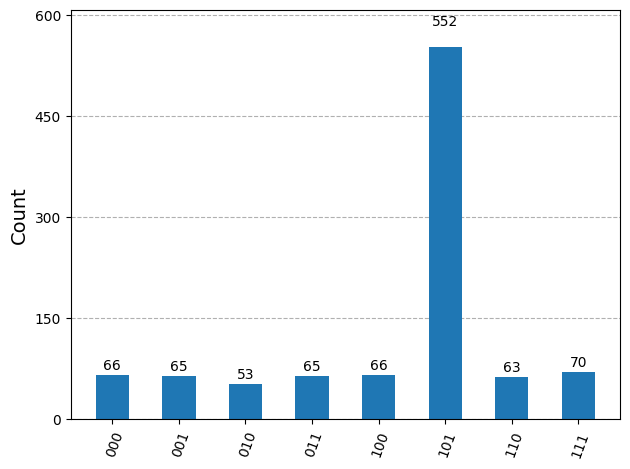

In [101]:
#Probar para k = 1, 2, 3, 4, 5

for k in range(1, 6):
    qc = QuantumCircuit(num_qubits1)
    qc.h(range(num_qubits1))
    qc.compose(grover_op1.power(k), inplace=True)

    sv = Statevector.from_instruction(qc)
    statistics = sv.sample_counts(1000)

    print(f"k={k}:")
    display(plot_histogram(statistics))

Se obtiene la máxima probabilidad con 2 iteracions

In [102]:
#Calculo valor teorico de iteraciones
it_teoricas = math.pi/4*math.sqrt(q1**n1)
print("Valor teorico de iteraciones:", it_teoricas)

Valor teorico de iteraciones: 2.221441469079183


Coincide con lo obtenido

### Caso n=2, m=5, q=4, número de qubits = 4

In [103]:
n2 = 2
m2 = 5
q2 = 4
num_qubits2 = 4
num_bits2 = int(np.ceil(np.log2(q2)))

In [104]:
#Generar instancia LWE
A2, s2, bm21, b20, b21 = generar_lwe(n2, m2, q2)

display(array_to_latex(A2, prefix="A2"))
display(array_to_latex(s2, prefix="s2"))

display(array_to_latex(bm21, prefix="bm21"))
display(array_to_latex(b20, prefix="b20"))
display(array_to_latex(b21, prefix="b21"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [105]:
#Calcular residuos para -1 0 y 1
rm21 = calcular_residuo(A2, s2, bm21, q2)
r20 = calcular_residuo(A2, s2, b20, q2)
r21 = calcular_residuo(A2, s2, b21, q2)

display(array_to_latex(rm21, prefix="rm21"))
display(array_to_latex(r20, prefix="r20"))
display(array_to_latex(r21, prefix="r21"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [106]:
#Comprobar condición 
print("bm1 cumple condicion:", cumple_condicion(rm21, q2))
print("b0 cumple condicion:", cumple_condicion(r20, q2))    
print("b1 cumple condicion:", cumple_condicion(r21, q2))

[1 1 1 1 1]
bm1 cumple condicion: True
[0 0 0 0 0]
b0 cumple condicion: True
[1 1 1 1 1]
b1 cumple condicion: True


<IPython.core.display.Latex object>

s en bits: [1 1 1 0]


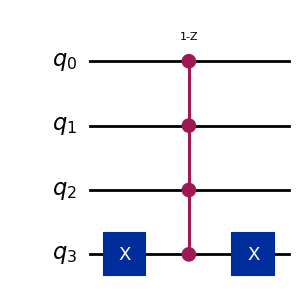

In [107]:
circuito2 = oracle(num_qubits2, num_bits2, s2, n2)
display(circuito2.draw(output="mpl"))

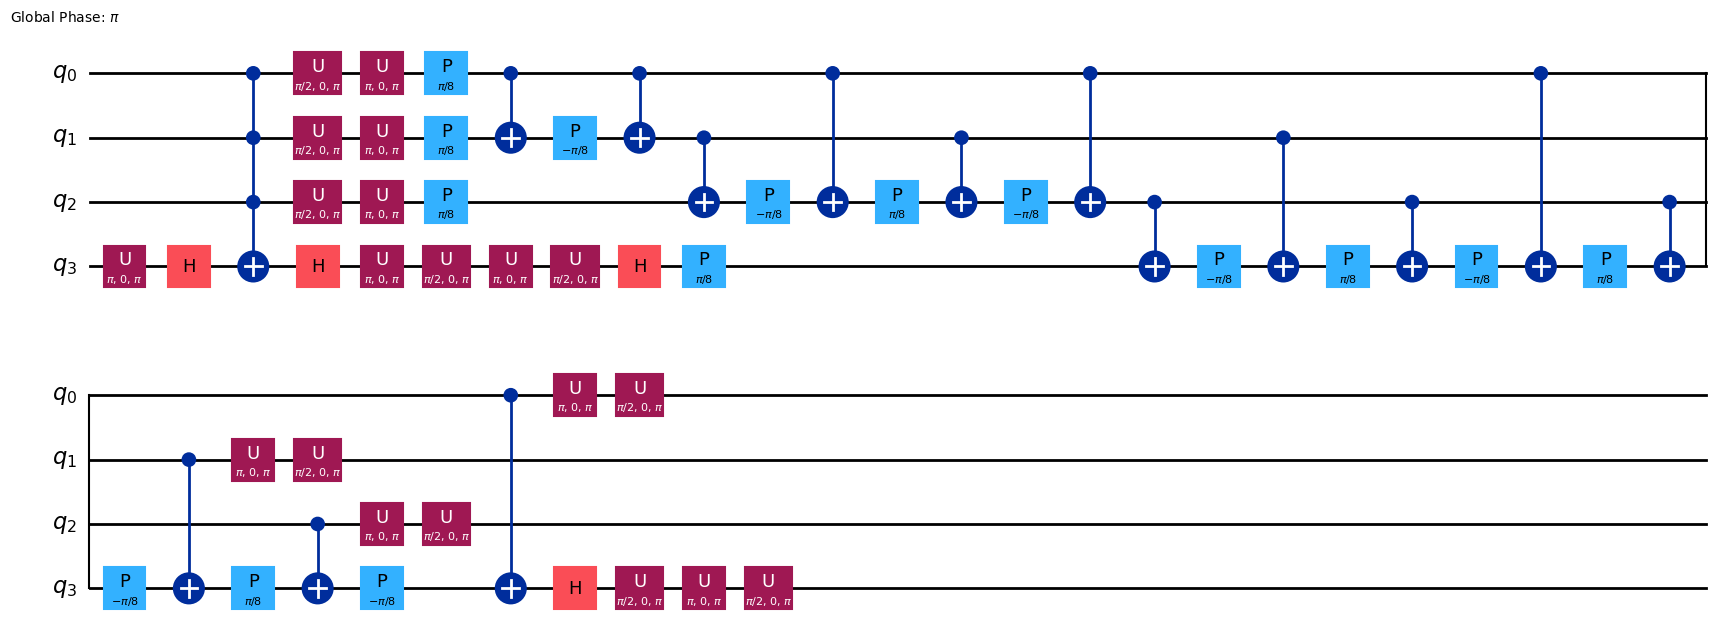

In [108]:
#Construir el operador de Grover
grover_op2 = grover_operator(circuito2)
grover_op2.decompose().draw(output="mpl", style="iqp")

k=1:


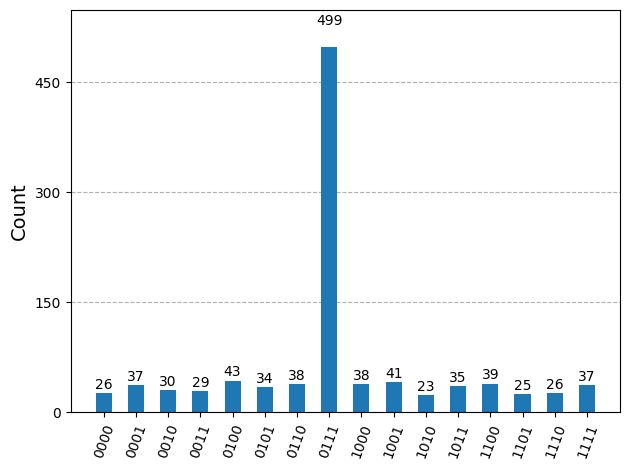

k=2:


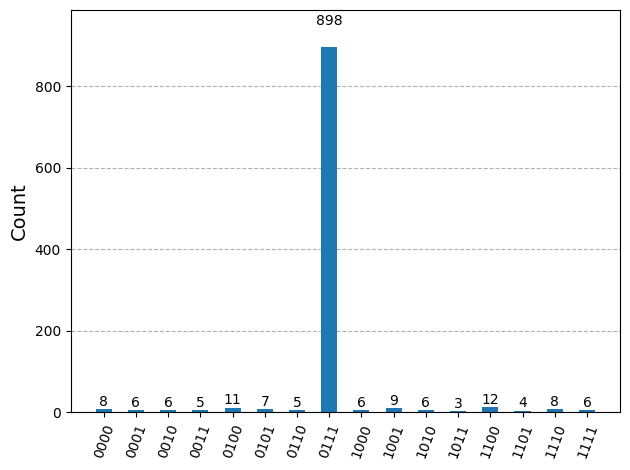

k=3:


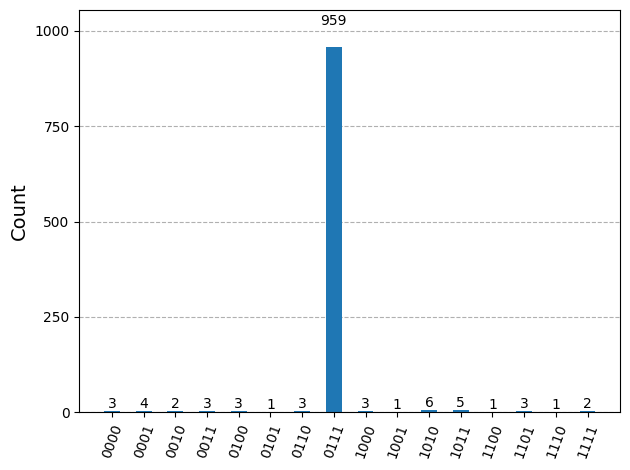

k=4:


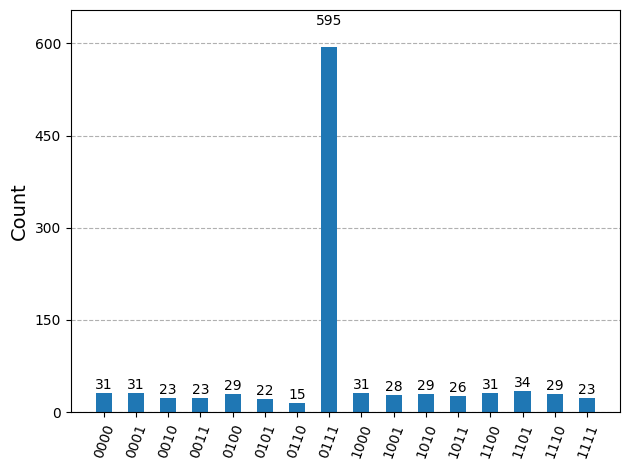

k=5:


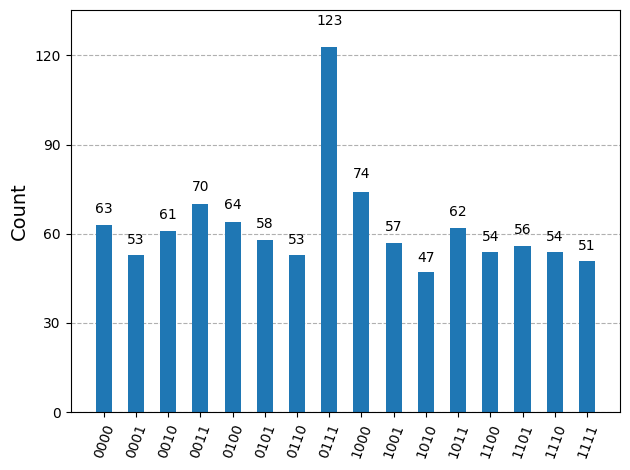

In [109]:
#Probar para k = 1, 2, 3, 4, 5

for k in range(1, 6):
    qc = QuantumCircuit(num_qubits2)
    qc.h(range(num_qubits2))
    qc.compose(grover_op2.power(k), inplace=True)

    sv = Statevector.from_instruction(qc)
    statistics = sv.sample_counts(1000)

    print(f"k={k}:")
    display(plot_histogram(statistics))

Se obtiene la máxima probabilidad con 3 iteraciones

In [110]:
#Calculo valor teorico de iteraciones
it_teoricas = math.pi/4*math.sqrt(q2**n2)
print("Valor teorico de iteraciones:", it_teoricas)

Valor teorico de iteraciones: 3.141592653589793


Coincide con lo obtenido

### Caso n=2, m=5, q=8, número de qubits = 5

In [111]:
n3 = 2
m3 = 5
q3 = 8
num_qubits3 = 6
num_bits3 = int(np.ceil(np.log2(q3)))

In [112]:
#Generar instancia LWE
A3, s3, bm31, b30, b31 = generar_lwe(n3, m3 ,q3)

display(array_to_latex(A3, prefix="A3"))
display(array_to_latex(s3, prefix="s3"))

display(array_to_latex(bm31, prefix="bm31"))
display(array_to_latex(b30, prefix="b30"))
display(array_to_latex(b31, prefix="b31"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [113]:
#Calcular residuos para -1 0 y 1
rm31 = calcular_residuo(A3, s3, bm31, q3)
r30 = calcular_residuo(A3, s3, b30, q3)
r31 = calcular_residuo(A3, s3, b31, q3)

display(array_to_latex(rm31, prefix="rm31"))
display(array_to_latex(r30, prefix="r30"))
display(array_to_latex(r31, prefix="r31"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [114]:
#Comprobar condición
print("bm1 cumple condicion:", cumple_condicion(rm31, q3))
print("b0 cumple condicion:", cumple_condicion(r30, q3))    
print("b1 cumple condicion:", cumple_condicion(r31, q3))

[1 1 1 1 1]
bm1 cumple condicion: True
[0 0 0 0 0]
b0 cumple condicion: True
[1 1 1 1 1]
b1 cumple condicion: True


<IPython.core.display.Latex object>

s en bits: [0 1 1 1 1 0]


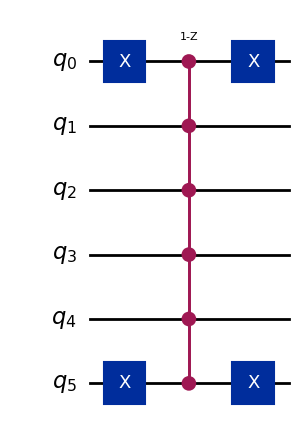

In [115]:
circuito3 = oracle(num_qubits3, num_bits3, s3, n3)
display(circuito3.draw(output="mpl"))

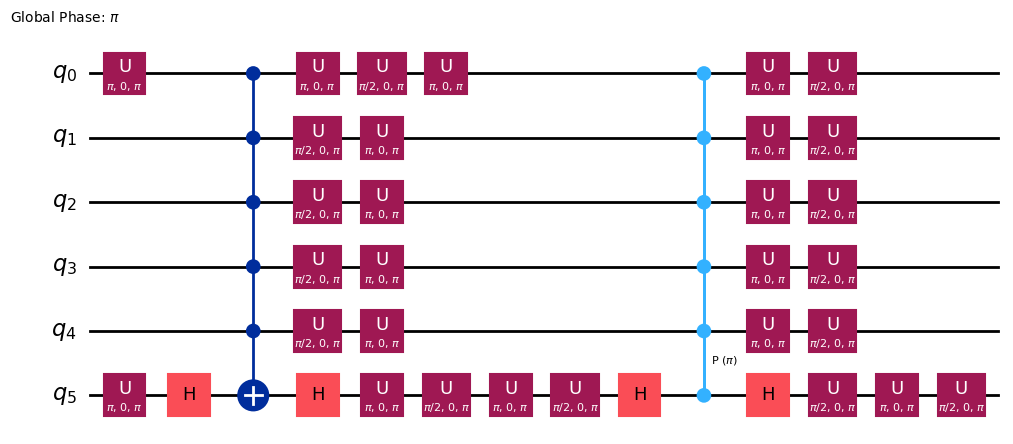

In [116]:
#Construir el operador de Grover
grover_op3 = grover_operator(circuito3)
grover_op3.decompose().draw(output="mpl", style="iqp")

k=1:


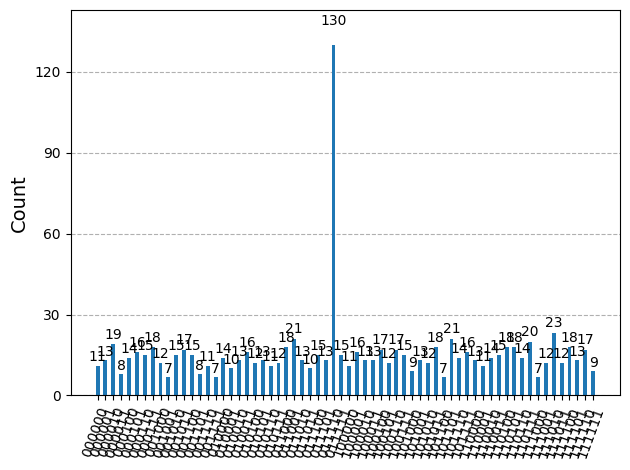

k=2:


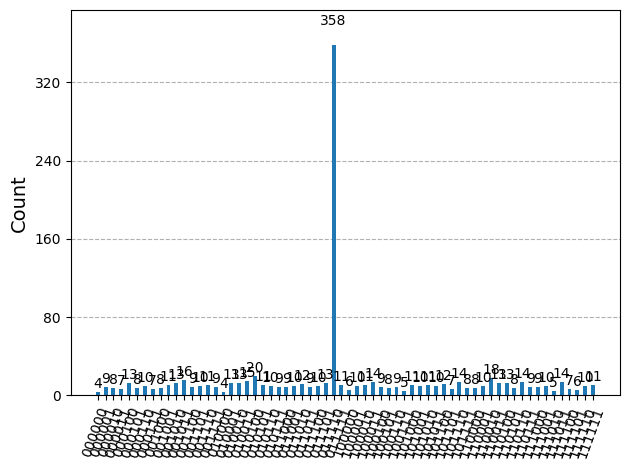

k=3:


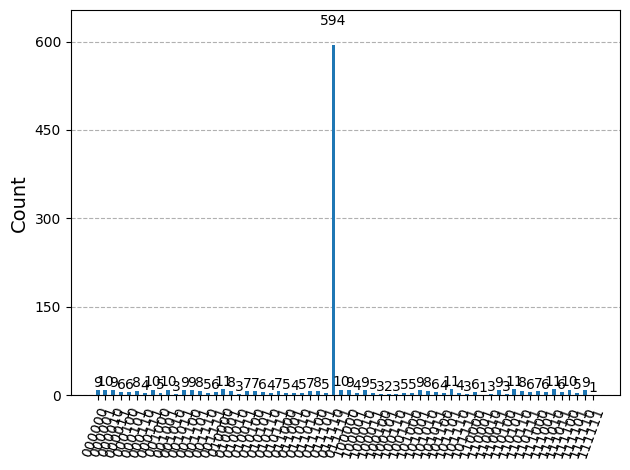

k=4:


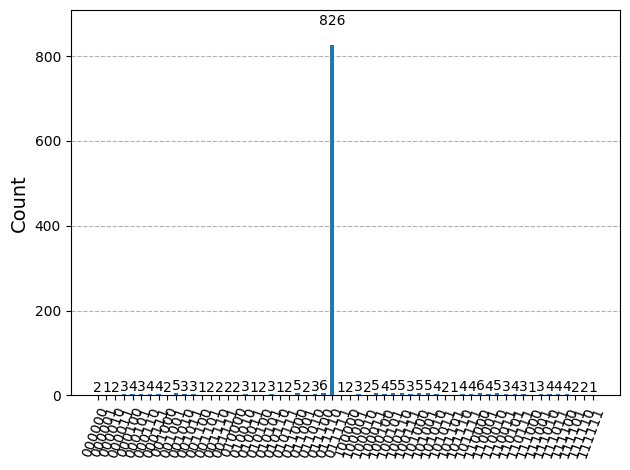

k=5:


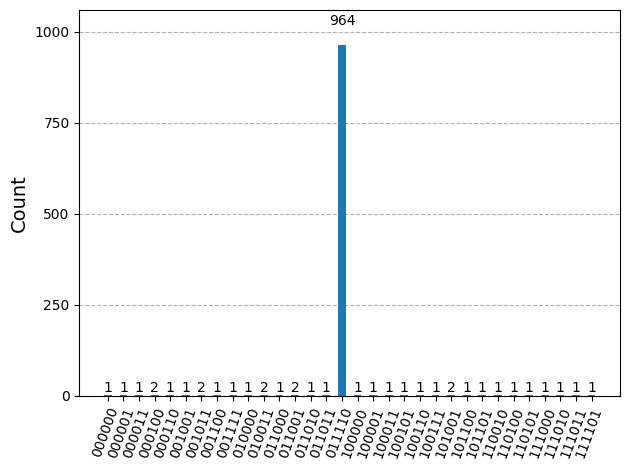

In [117]:
for k in range(1, 6):

    #Crea circuito
    qc = QuantumCircuit(num_qubits3)

    #Aplica hadamard a los qubits para crear superposición
    qc.h(range(num_qubits3))
    
    #Aplica Grover k veces
    qc.compose(grover_op3.power(k), inplace=True)
    
    #Obtener probabilidades
    sv = Statevector.from_instruction(qc)
    statistics = sv.sample_counts(1000)

    print(f"k={k}:")
    display(plot_histogram(statistics))

Se obtiene la máxima probabilidad con 5 iteraciones

In [58]:
#Calculo valor teorico de iteraciones
it_teoricas = math.pi/4*math.sqrt(q3**n3)
print("Valor teorico de iteraciones:", it_teoricas)

Valor teorico de iteraciones: 6.283185307179586


No se ha llegado a ese número de iteraciones pero en los resultados obtenidos, se puede observar que según se acerca a 6 el número de iteraciones, la probabilidad va subiendo.